# Stock Market Trend Analysis

In [6]:
#importing relevant libraries 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [8]:
#Importing the data
cmpy_info = pd.read_csv('company_info.csv')
mrkt_indices = pd.read_csv('market_indices.csv')
stk_prices = pd.read_csv('stock_prices.csv')
stk_prices_indicators = pd.read_csv('stock_prices_with_indicators.csv')

In [9]:
#Exploring company information 
cmpy_info.head()

,ticker,company_name,sector,ipo_date
0,STK001,TechCorp,Technology,2021-04-10
1,STK002,DataSystems,Technology,2016-10-12
2,STK003,CloudNine,Technology,2016-01-18
3,STK004,CyberShield,Technology,2022-02-21
4,STK005,MediPharm,Healthcare,2018-03-05


In [10]:
cmpy_info.tail()

,ticker,company_name,sector,ipo_date
15,STK016,ShopEasy,Consumer,2019-06-04
16,STK017,PowerGen,Energy,2016-02-08
17,STK018,GreenEnergy,Energy,2016-02-02
18,STK019,OilCorp,Energy,2016-08-19
19,STK020,RenewTech,Energy,2017-09-11


In [11]:
cmpy_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   ticker        20 non-null     object
 1   company_name  20 non-null     object
 2   sector        20 non-null     object
 3   ipo_date      20 non-null     object
dtypes: object(4)
memory usage: 772.0+ bytes


In [13]:
cmpy_info['company_name'].nunique()

20

In [57]:
print(cmpy_info.duplicated().sum())

0


#### This data contains information about 20 companies, the sector they work in, an idenifier for their ticker and the date for their IPO. 
#### There are 4 columns and 20 rows. The IPO date column is incorrectly identified as an object. There are no duplicates in the dataset.

In [41]:
#Transforming the IPO column into date
cmpy_info['ipo_date'] = pd.to_datetime(cmpy_info['ipo_date'])

In [42]:
cmpy_info.head()

,ticker,company_name,sector,ipo_date
0,STK001,TechCorp,Technology,2021-04-10
1,STK002,DataSystems,Technology,2016-10-12
2,STK003,CloudNine,Technology,2016-01-18
3,STK004,CyberShield,Technology,2022-02-21
4,STK005,MediPharm,Healthcare,2018-03-05


In [44]:
cmpy_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ticker        20 non-null     object        
 1   company_name  20 non-null     object        
 2   sector        20 non-null     object        
 3   ipo_date      20 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(3)
memory usage: 772.0+ bytes


##### The correct format is now observed for the column

In [14]:
mrkt_indices.head()

,date,sp500_close,nasdaq_close,vix_close,treasury_10y,dollar_index,market_regime
0,2021-01-04,3891.04,12952.02,20.48,1.496,90.07,bull
1,2021-01-05,3847.20,13116.52,19.89,1.504,90.73,bull
2,2021-01-06,3878.24,12818.48,20.02,1.507,90.46,bull
3,2021-01-07,3803.95,13290.11,19.59,1.498,90.67,bull
4,2021-01-08,3715.64,13365.73,20.14,1.498,90.64,bull


In [16]:
mrkt_indices.tail()

,date,sp500_close,nasdaq_close,vix_close,treasury_10y,dollar_index,market_regime
775,2023-12-25,4247.26,5350.73,12.45,2.476,92.05,sideways
776,2023-12-26,4301.17,5335.90,13.04,2.510,92.23,sideways
777,2023-12-27,4329.32,5301.90,12.42,2.533,92.29,sideways
778,2023-12-28,4410.97,5317.69,11.99,2.529,91.93,sideways
779,2023-12-29,4403.39,5242.09,11.50,2.546,91.60,sideways


In [15]:
mrkt_indices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           780 non-null    object 
 1   sp500_close    780 non-null    float64
 2   nasdaq_close   780 non-null    float64
 3   vix_close      780 non-null    float64
 4   treasury_10y   780 non-null    float64
 5   dollar_index   780 non-null    float64
 6   market_regime  780 non-null    object 
dtypes: float64(5), object(2)
memory usage: 42.8+ KB


In [59]:
print(mrkt_indices.duplicated().sum())

0


#### There are no nulls in the market indices data. There are a total of 7 columns and 780 rows in this dataset. The date column however is not in the right format.

In [46]:
mrkt_indices.date = pd.to_datetime(mrkt_indices.date)

In [47]:
mrkt_indices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 780 entries, 0 to 779
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           780 non-null    datetime64[ns]
 1   sp500_close    780 non-null    float64       
 2   nasdaq_close   780 non-null    float64       
 3   vix_close      780 non-null    float64       
 4   treasury_10y   780 non-null    float64       
 5   dollar_index   780 non-null    float64       
 6   market_regime  780 non-null    object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 42.8+ KB


###### The date column is fixed now. 

In [17]:
stk_prices.head()

,ticker,date,open,high,low,close,volume,adjusted_close
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644,160.11
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685,162.36
2,STK001,2021-01-06,161.89,162.51,160.94,161.78,1449177,161.78
3,STK001,2021-01-07,163.33,167.90,163.33,167.07,1534833,167.07
4,STK001,2021-01-08,168.20,168.20,164.12,165.68,848261,165.68


In [18]:
stk_prices.tail()

,ticker,date,open,high,low,close,volume,adjusted_close
15595,STK020,2023-12-25,75.77,75.77,71.39,72.81,1189734,72.81
15596,STK020,2023-12-26,73.11,78.51,73.11,77.81,1358179,77.81
15597,STK020,2023-12-27,78.74,78.74,76.32,76.89,1436557,76.89
15598,STK020,2023-12-28,74.46,75.85,73.62,75.10,1419570,75.10
15599,STK020,2023-12-29,74.28,77.87,74.05,75.93,1366923,75.93


In [19]:
stk_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ticker          15600 non-null  object 
 1   date            15600 non-null  object 
 2   open            15600 non-null  float64
 3   high            15600 non-null  float64
 4   low             15600 non-null  float64
 5   close           15600 non-null  float64
 6   volume          15600 non-null  int64  
 7   adjusted_close  15600 non-null  float64
dtypes: float64(5), int64(1), object(2)
memory usage: 975.1+ KB


In [60]:
print(stk_prices.duplicated().sum())

0


##### There are no nulls in the stock prices data either. A total of 8 columns and 15,600 rows are in this dataset. The date column is however incorrectly identified as an object. 

In [49]:
stk_prices.date = pd.to_datetime(stk_prices.date)

In [50]:
stk_prices.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15600 entries, 0 to 15599
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   ticker          15600 non-null  object        
 1   date            15600 non-null  datetime64[ns]
 2   open            15600 non-null  float64       
 3   high            15600 non-null  float64       
 4   low             15600 non-null  float64       
 5   close           15600 non-null  float64       
 6   volume          15600 non-null  int64         
 7   adjusted_close  15600 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(1), object(1)
memory usage: 975.1+ KB


#### The data is now in the right format

In [20]:
stk_prices_indicators.head()

,ticker,date,open,high,low,close,volume,adjusted_close,sma_20,sma_50,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
0,STK001,2021-01-04,158.09,160.97,158.09,160.11,962644.0,160.11,160.110000,160.110000,...,2.88,2.880,962644.00,1.000000,NaN,NaN,0.000000,NaN,0.026357,Uptrend
1,STK001,2021-01-05,163.16,165.50,160.76,162.36,1312685.0,162.36,161.235000,161.235000,...,5.39,4.135,1137664.50,1.153842,NaN,NaN,0.006977,NaN,0.018169,Sideways
2,STK001,2021-01-06,161.89,162.51,160.94,161.78,1449177.0,161.78,161.416667,161.416667,...,1.57,3.280,1241502.00,1.167277,NaN,NaN,0.002251,0.012463,-0.012301,Sideways
3,STK001,2021-01-07,163.33,167.90,163.33,167.07,1534833.0,167.07,162.830000,162.830000,...,6.12,3.990,1314834.75,1.167320,NaN,NaN,0.026039,0.018138,-0.061950,Downtrend
4,STK001,2021-01-08,168.20,168.20,164.12,165.68,848261.0,165.68,163.400000,163.400000,...,4.08,4.008,1221520.00,0.694431,NaN,NaN,0.013953,0.018663,-0.070196,Downtrend


In [21]:
stk_prices_indicators.tail()

,ticker,date,open,high,low,close,volume,adjusted_close,sma_20,sma_50,...,true_range,atr_14,volume_sma_20,volume_ratio,momentum_10,momentum_20,price_to_sma_50,volatility_20,future_return_5d,trend_label
15497,STK020,2023-12-18,76.16,77.62,75.43,76.39,1029767.0,76.39,67.238,58.9968,...,2.52,3.170000,1225177.90,0.840504,0.106620,0.344658,0.294816,0.024476,-0.046865,Downtrend
15498,STK020,2023-12-19,76.93,78.72,75.06,76.97,1031912.0,76.97,68.222,59.4778,...,3.66,3.246429,1208916.60,0.853584,0.170468,0.343515,0.294096,0.024489,0.010913,Sideways
15499,STK020,2023-12-20,77.89,77.89,76.83,77.24,1057795.0,77.24,69.164,59.9724,...,1.06,3.070000,1196352.10,0.884184,0.151118,0.322603,0.287926,0.024602,-0.004531,Sideways
15500,STK020,2023-12-21,76.88,78.90,74.48,76.74,1072067.0,76.74,70.048,60.4466,...,4.42,3.205714,1204305.15,0.890195,0.142474,0.299357,0.269550,0.025036,-0.021371,Downtrend
15501,STK020,2023-12-22,78.10,78.10,75.98,76.81,1259507.0,76.81,70.747,60.9676,...,2.12,3.138571,1205189.10,1.045070,0.097442,0.222505,0.259849,0.022163,-0.011457,Sideways


In [22]:
stk_prices_indicators.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15502 entries, 0 to 15501
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticker            15502 non-null  object 
 1   date              15502 non-null  object 
 2   open              15502 non-null  float64
 3   high              15502 non-null  float64
 4   low               15502 non-null  float64
 5   close             15502 non-null  float64
 6   volume            15502 non-null  float64
 7   adjusted_close    15502 non-null  float64
 8   sma_20            15192 non-null  float64
 9   sma_50            15502 non-null  float64
 10  sma_200           15502 non-null  float64
 11  ema_12            15502 non-null  float64
 12  ema_26            15502 non-null  float64
 13  macd              15191 non-null  float64
 14  macd_signal       15502 non-null  float64
 15  macd_histogram    15502 non-null  float64
 16  rsi_14            15172 non-null  float6

In [61]:
print(stk_prices_indicators.duplicated().sum())

0


In [65]:
stk_prices_indicators.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
15497    False
15498    False
15499    False
15500    False
15501    False
Length: 15502, dtype: bool

##### There are some evident null values among the 31 columns and 15,502 rows. The date column is also not in the right data format. There are no duplicates in observations. 

In [52]:
stk_prices_indicators.date = pd.to_datetime(stk_prices_indicators.date)

In [53]:
stk_prices_indicators.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15502 entries, 0 to 15501
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   ticker            15502 non-null  object        
 1   date              15502 non-null  datetime64[ns]
 2   open              15502 non-null  float64       
 3   high              15502 non-null  float64       
 4   low               15502 non-null  float64       
 5   close             15502 non-null  float64       
 6   volume            15502 non-null  float64       
 7   adjusted_close    15502 non-null  float64       
 8   sma_20            15192 non-null  float64       
 9   sma_50            15502 non-null  float64       
 10  sma_200           15502 non-null  float64       
 11  ema_12            15502 non-null  float64       
 12  ema_26            15502 non-null  float64       
 13  macd              15191 non-null  float64       
 14  macd_signal       1550

In [25]:
stk_prices_indicators.isnull().sum()

ticker                0
date                  0
open                  0
high                  0
low                   0
close                 0
volume                0
adjusted_close        0
sma_20              310
sma_50                0
sma_200               0
ema_12                0
ema_26                0
macd                311
macd_signal           0
macd_histogram        0
rsi_14              330
bb_middle             0
bb_upper             20
bb_lower             20
bb_width            331
true_range            0
atr_14                0
volume_sma_20         0
volume_ratio        310
momentum_10         200
momentum_20         400
price_to_sma_50       0
volatility_20        40
future_return_5d      0
trend_label           0
dtype: int64

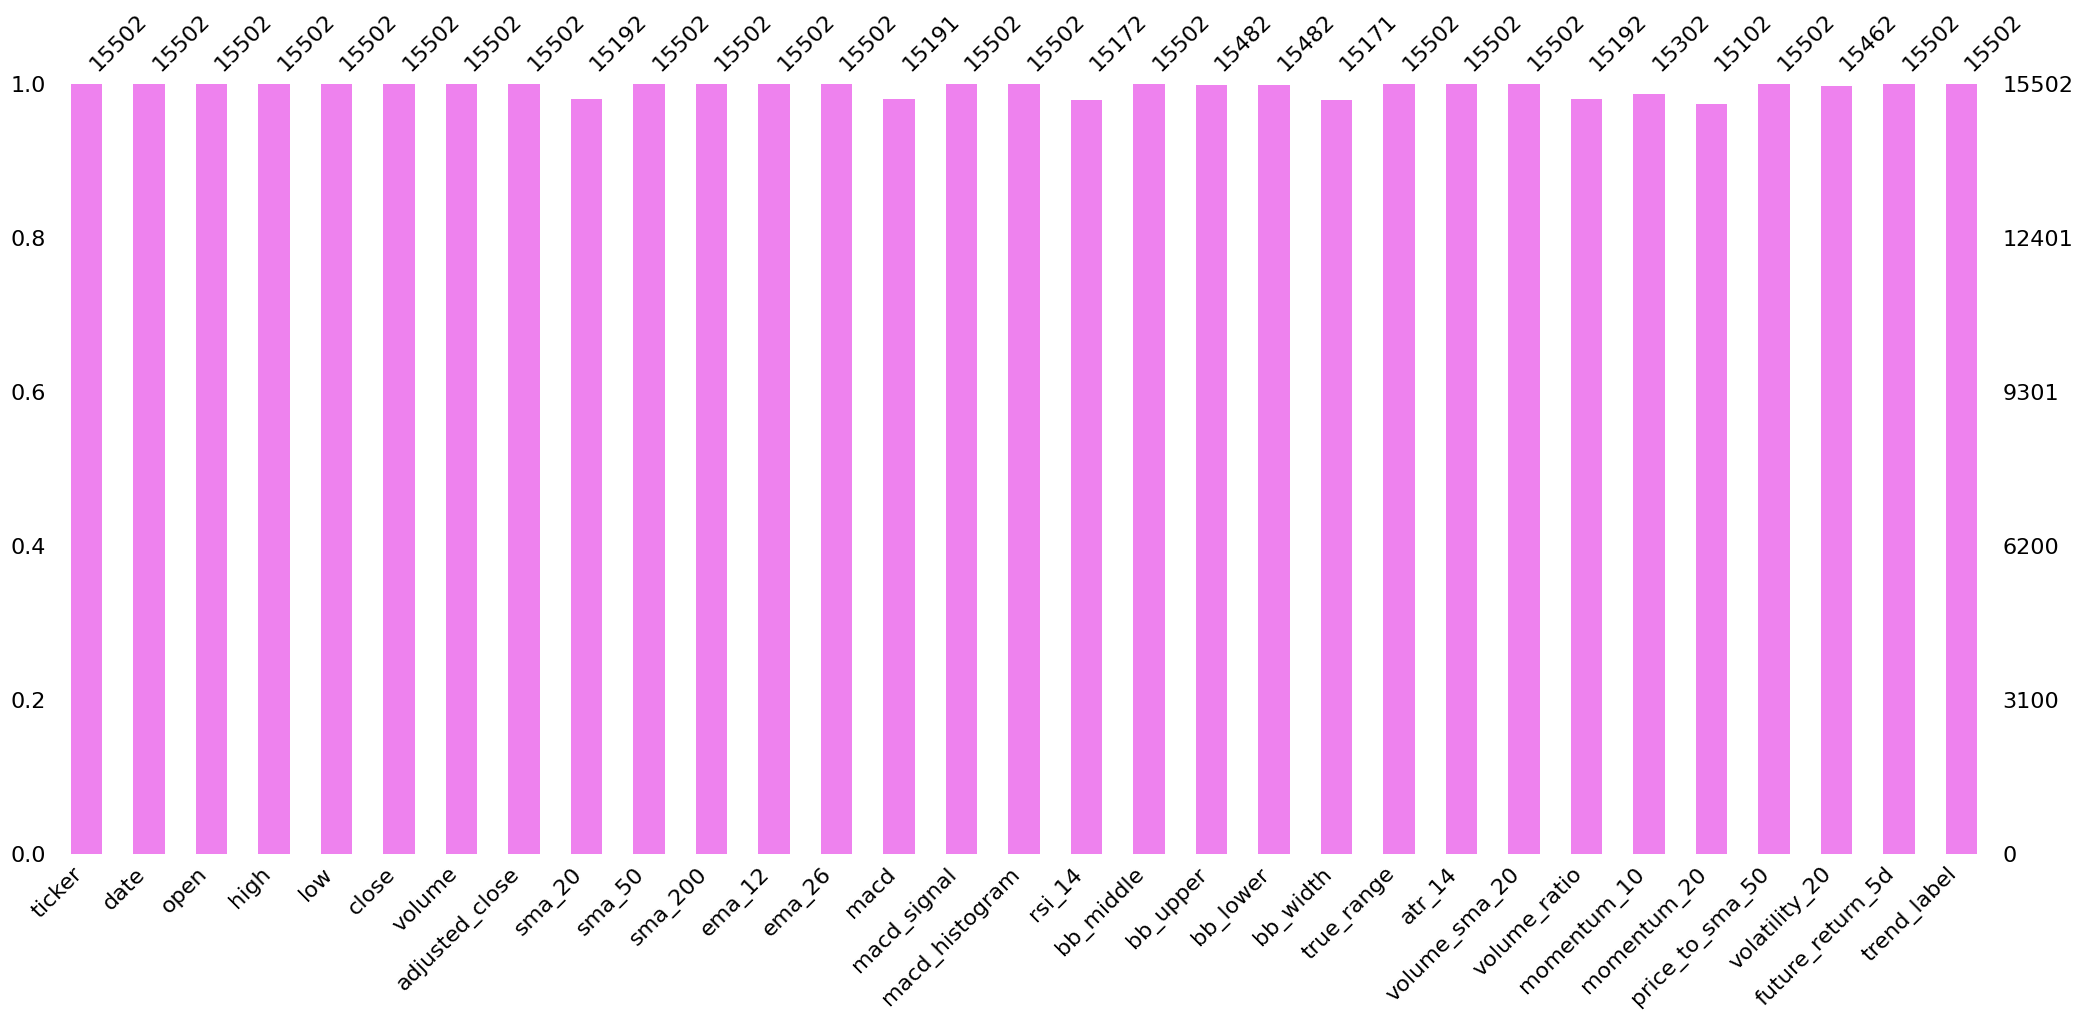

In [29]:
msno.bar(stk_prices_indicators, color='violet');

In [54]:
round(stk_prices_indicators.isnull().mean(),2) * 100

ticker              0.0
date                0.0
open                0.0
high                0.0
low                 0.0
close               0.0
volume              0.0
adjusted_close      0.0
sma_20              2.0
sma_50              0.0
sma_200             0.0
ema_12              0.0
ema_26              0.0
macd                2.0
macd_signal         0.0
macd_histogram      0.0
rsi_14              2.0
bb_middle           0.0
bb_upper            0.0
bb_lower            0.0
bb_width            2.0
true_range          0.0
atr_14              0.0
volume_sma_20       0.0
volume_ratio        2.0
momentum_10         1.0
momentum_20         3.0
price_to_sma_50     0.0
volatility_20       0.0
future_return_5d    0.0
trend_label         0.0
dtype: float64

##### The null values are within the following columns: 
- *sma_20*
- *macd*
- *rsi_14*
- *bb_upper*
- *bb_lower*
- *bb_width*
- *volume_ratio*
- *momentum_10*
- *momentum_20*
- *volatility_20*

The null values in each column does not exceed 3% (momentum_20 has the highest number of nulls) .